<h4><b>Regressão com Máquinas de Vetores de Suporte (SVR)</b></h4>
<p>Cross-validation</p>

In [16]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, learning_curve, KFold, cross_val_score, learning_curve
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
import plotly.graph_objects as go
import matplotlib.pyplot as plt

In [3]:
path = '/media/marcos/500GB/00_datasets/post_processing/post_processing_dataset.csv'
df = pd.read_csv(path)

In [4]:
df = df[[
    'line_category',
    'line_color',
    'station_initial_latitude',
    'station_initial_longitude',
    'station_final_latitude',
    'station_final_longitude',
    'distance',
    'average_speed_kh',
    'duration'
]]

In [5]:
X = df.iloc[:,0:8].values
y = df.iloc[:,8].values

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

scaler_x = StandardScaler()
X_train_scaled = scaler_x.fit_transform(X_train)
X_test_scaled = scaler_x.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).ravel()

regressor_svr = SVR(kernel='rbf')

cv = KFold(n_splits=5, shuffle=True, random_state=0)

In [7]:
def mae_inversed(estimator, X, y):
    y_pred_scaled = estimator.predict(X)
    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
    y_true = scaler_y.inverse_transform(y.reshape(-1, 1)).ravel()
    return mean_absolute_error(y_true, y_pred)

mae_scores_train = cross_val_score(regressor_svr, X_train_scaled, y_train_scaled, cv=cv, scoring=mae_inversed)

def mae_test_inversed(estimator, X, y):
    y_pred_scaled = estimator.predict(X)
    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
    y_true = scaler_y.inverse_transform(y.reshape(-1, 1)).ravel()
    return mean_absolute_error(y_true, y_pred)

mae_scores_test = cross_val_score(regressor_svr, X_test_scaled, y_test_scaled, cv=cv, scoring=mae_test_inversed)

In [8]:
regressor_svr.fit(X_train_scaled, y_train_scaled)

SVR()

In [9]:
y_train_pred_scaled = regressor_svr.predict(X_train_scaled)
y_test_pred_scaled = regressor_svr.predict(X_test_scaled)

In [10]:
y_train_pred = scaler_y.inverse_transform(y_train_pred_scaled.reshape(-1, 1)).ravel()
y_test_pred = scaler_y.inverse_transform(y_test_pred_scaled.reshape(-1, 1)).ravel()

In [15]:
mae_train = mean_absolute_error(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)

mae_train_std = np.std(np.abs(y_train_pred - y_train))
mae_test_std = np.std(np.abs(y_test_pred - y_test))

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

mse_train_std = np.std((y_train_pred - y_train) ** 2)
mse_test_std = np.std((y_test_pred - y_test) ** 2)

rmse_train = np.sqrt(mse_train)
rmse_test = np.sqrt(mse_test)

rmse_train_std = np.std(np.sqrt((y_train_pred - y_train) ** 2))
rmse_test_std = np.std(np.sqrt((y_test_pred - y_test) ** 2)) 

r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

print("MAE para cada fold na Cross-Validation (dados de treino):")
for i, score in enumerate(mae_scores_train, 1):
    print(f"Fold {i}: {score:.4f}")
print('-'*60)
print("MAE para cada fold na Cross-Validation (dados de teste):")
for i, score in enumerate(mae_scores_test, 1):
    print(f"Fold {i}: {score:.4f}")
print('-'*60)
print(f"MAE treino: {mae_scores_train.mean():.4f} \u00b1 {mae_scores_train.std():.4f}")
print(f"MAE teste: {mae_test:.4f} \u00b1 {mae_test_std:.4f}")
print('-'*60)
print(f"MSE treino: {mse_train:.4f} \u00b1 {mse_train_std:.4f}")
print(f"MSE teste: {mse_test:.4f} \u00b1 {mse_test_std:.4f}")
print('-'*60)
print(f"RMSE treino: {rmse_train:.4f} \u00b1 {rmse_train_std:.4f}")
print(f"RMSE teste: {rmse_test:.4f} \u00b1 {rmse_test_std:.4f}")
print('-'*60)
print(f"R² treino: {r2_train:.4f}")
print(f"R² teste: {r2_test:.4f}")

MAE para cada fold na Cross-Validation (dados de treino):
Fold 1: 26.3770
Fold 2: 26.9483
Fold 3: 27.1184
Fold 4: 26.8316
Fold 5: 25.1984
------------------------------------------------------------
MAE para cada fold na Cross-Validation (dados de teste):
Fold 1: 37.5122
Fold 2: 34.5338
Fold 3: 41.4880
Fold 4: 34.4905
Fold 5: 36.1296
------------------------------------------------------------
MAE treino: 26.4947 ± 0.6932
MAE teste: 25.8052 ± 22.9934
------------------------------------------------------------
MSE treino: 946.1328 ± 1902.3784
MSE teste: 1194.6055 ± 4491.2501
------------------------------------------------------------
RMSE treino: 30.7593 ± 18.1984
RMSE teste: 34.5631 ± 22.9934
------------------------------------------------------------
R² treino: 0.9968
R² teste: 0.9959


In [17]:
train_sizes, train_scores, test_scores = learning_curve(
    regressor_svr,                  # Modelo SVR
    X_train,                     # Dados de entrada
    y_train.ravel(),             # Rótulos (vetor)
    cv=5,                               # Número de folds na validação cruzada
    scoring='neg_mean_absolute_error',   # Métrica de avaliação
    n_jobs=-1,                          # Paralelização
    train_sizes=np.linspace(0.1, 1.0, 10)  # Frações do conjunto de treinamento
)

In [18]:
train_mean = -np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = -np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

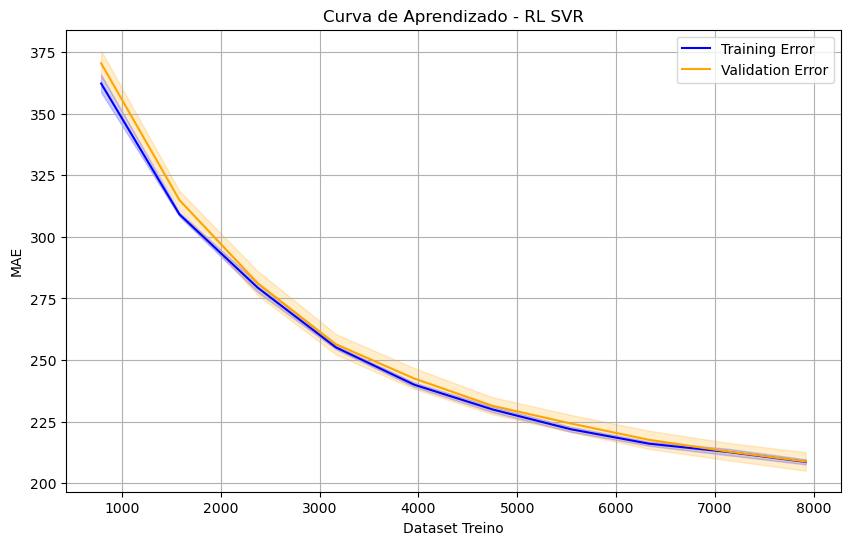

In [19]:
plt.figure(figsize=(10, 6))

# Plotar a média do erro no conjunto de treino
plt.plot(train_sizes, train_mean, label="Training Error", color="blue")

# Adicionar faixa de desvio padrão
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, color="blue", alpha=0.2)

# Plotar a média do erro no conjunto de validação
plt.plot(train_sizes, test_mean, label="Validation Error", color="orange")

# Adicionar faixa de desvio padrão
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, color="orange", alpha=0.2)

# Detalhes do gráfico
plt.title("Curva de Aprendizado - RL SVR")
plt.xlabel("Dataset Treino")
plt.ylabel("MAE")
plt.legend(loc="best")
plt.grid()
plt.savefig('rl_svr_learning_curve.png', dpi=300, bbox_inches='tight')
plt.show()